<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/Regress%C3%A3oipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


In [4]:
from google.colab import files
uploaded = files.upload()

Saving smoke_detection_iot.csv to smoke_detection_iot.csv


In [6]:

# Carregar a base de dados
df = pd.read_csv("smoke_detection_iot.csv")

# Verificar as 5 primeiras linhas (sem print)
df.head()

# Verificar tipos de dados
df.dtypes

# Verificar valores nulos
df.isnull().sum()

# Informações gerais do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


In [12]:
# Renomear a coluna "Fire Alarm" para "Fire_Alarm"
df.rename(columns={"Fire Alarm": "Fire_Alarm"}, inplace=True)

Para esse projeto, o modelo mais adequado é a Regressão Logística, porque estamos lidando com um problema de classificação binária: a coluna Fire_Alarm indica apenas duas possibilidades, alarme ligado ou desligado. Esse tipo de situação combina muito bem com a regressão logística, já que ela foi criada justamente para prever a probabilidade de um evento acontecer ou não. Além disso, é um modelo simples, rápido de treinar e funciona muito bem com dados numéricos de sensores, como temperatura, umidade, CO₂ e outros presentes na base. Ele também permite interpretar facilmente como cada variável influencia o acionamento do alarme, o que é útil em aplicações de IoT e segurança. Embora existam modelos mais complexos, como Random Forest , a regressão logística é a escolha mais natural e eficiente para começar, especialmente quando o objetivo é prever um alarme de incêndio de forma clara e direta.


In [17]:
# Separar X e y
y = df["Fire_Alarm"]
X = df.drop("Fire_Alarm", axis=1)

# Instanciar o modelo
modelo = LogisticRegression()


In [18]:
# Definir número de folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Rodar validação cruzada
resultados = cross_val_score(modelo, X, y, cv=kfold, scoring='accuracy')

resultados


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([0.95537282, 0.96032253, 0.95776784, 0.95704934, 0.95665017])

In [22]:
# Resolvendo a convergência
modelo = LogisticRegression(max_iter=1000)

In [23]:
# Rodando novamente a validação cruzada
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = cross_val_score(modelo, X, y, cv=kfold, scoring='accuracy')
resultados

array([0.98770557, 0.97756666, 0.98938209, 0.97692799, 0.97636915])

Avaliação de cada fold
- Fold 1: 0.9877 → desempenho excelente
- Fold 2: 0.9775 → muito bom
- Fold 3: 0.9893 → excelente
- Fold 4: 0.9769 → muito bom
- Fold 5: 0.9763 → muito bom
Os valores são altos e consistentes, o que indica que o modelo está estável e generaliza bem.


In [27]:
# Cálculo da média e desvio padrão
media = resultados.mean()
desvio = resultados.std()

media, desvio

(np.float64(0.9815902919999999), np.float64(0.005714818269811912))

- Média da acurácia: aproximadamente 0.981 (98.1%)
- Desvio padrão: muito baixo → o modelo é consistente entre os folds


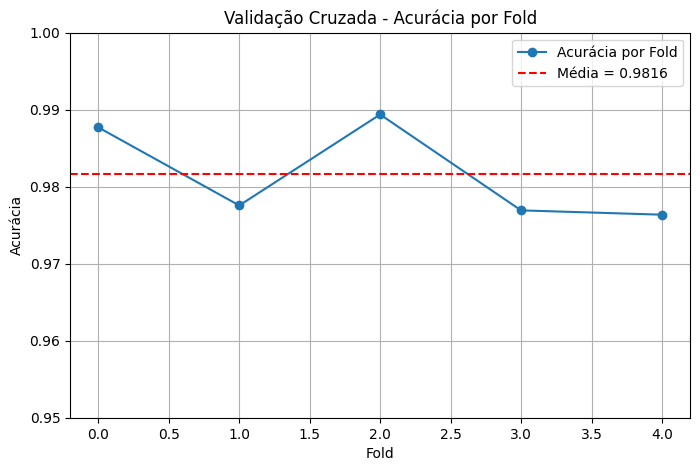

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados da validação cruzada
resultados = np.array([0.98770557, 0.97756666, 0.98938209, 0.97692799, 0.97636915])

# Cálculo da média
media = resultados.mean()

# Criar o gráfico
plt.figure(figsize=(8,5))
plt.plot(resultados, marker='o', linestyle='-', label='Acurácia por Fold')
plt.axhline(media, color='red', linestyle='--', label=f'Média = {media:.4f}')

plt.title('Validação Cruzada - Acurácia por Fold')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.ylim(0.95, 1.0)
plt.legend()
plt.grid(True)
plt.show()


O modelo de Regressão Logística apresentou excelente desempenho, com acurácia média acima de 98% e variação mínima entre os folds. Isso mostra que ele está aprendendo bem os padrões da base e não está sofrendo com instabilidade ou overfitting.
